### Exercise: Frequentist Coverage and Loss of Identifiability in NV Center ODMR

**The Physics Context:**
In quantum sensing, Nitrogen-Vacancy (NV) centers in diamond are read out using Optically Detected Magnetic Resonance (ODMR). You sweep a microwave frequency across the resonance and count the emitted photons. At the resonance frequency, the fluorescence drops, creating a "dip" in the spectrum.

To make the numerics manageable, our variable $\nu$ represents the **detuning** (in MHz) from the expected resonance (which is typically ~2.87 GHz). Therefore, a sweep from -5 to +5 means we are sweeping $\pm 5$ MHz around the center.

**The Statistical Model:**
Because we are counting independent photons, the number of observed photons $N_i$ at each discrete frequency point $\nu_i$ follows a Poisson distribution. The expected rate $\lambda(\nu_i)$ is modeled as a constant background $B$ minus a Lorentzian dip of amplitude $A$ (the contrast) and width $\gamma$:
$$\lambda(\nu_i) = B - A \frac{\gamma^2}{(\nu_i - \nu_0)^2 + \gamma^2}$$

The physical meaning and typical values of the parameters for our toy model are:
* **$B$ (Background):** Base photon counts per measurement point (True value = 1000).
* **$A$ (Amplitude/Contrast):** The depth of the dip in photon counts.
* **$\nu_0$ (Center):** The true resonance detuning (True value = 0.0 MHz).
* **$\gamma$ (Linewidth):** The width of the resonance (True value = 1.0 MHz).

**The Goal:**
If the true contrast $A$ is very weak, the signal gets buried in the Poisson noise ($\sqrt{B}$). In this regime, the linewidth $\gamma$ becomes completely unconstrained (a flat likelihood). This is called a "loss of identifiability." Your goal is to study how this affects the 2D Confidence Region of $(A, \gamma)$ and whether Wilks' theorem (which predicts $2\Delta\text{NLL}$ follows a $\chi^2$ distribution) holds at varying signal-to-noise ratios.

**Step-by-Step Instructions:**

1. **The Generative Model & Likelihood:** * Write a Python function `rate_model(nu, B, A, nu0, gamma)` that returns the expected rate.
   * Write a function to generate toy datasets with Poisson fluctuations for the number of photons at 50 discrete points of the frequency detuning $\nu$ between -5 and 5.
   * Write a custom Negative Log-Likelihood (NLL) function for Poisson data.
2. **The Fitter:**
   * Set up an `iminuit.Minuit` object. Set sensible limits (e.g., $B>0, A>0, \gamma>0$).
3. **Checking 2D Coverage (The Core Loop):**
   * Write a function that runs $N_{toys} = 300$ pseudo-experiments for a given true value of $A$.
   * For each toy, perform a fit to find the MLE for the parameters.
   * Then calculate a 2D confidence interval at 68.3% level for the parameters of interest $A$ and $\gamma$.
   * Check if the 2D confidence interval includes the true value of $A$ and $\gamma$ and keep track of the coverage fraction.
4. **Visualizing Wilks' Theorem:**
   * We use a test statistic $t$ based on the profiled likelihood ratio to get the 2D confidence interval of the POIs $A$ and $\gamma$.
   * Plot a histogram of your $t$ values. Overlay the theoretical PDF predicted by Wilks' theorem.
5. **Scanning the Contrast:**
   * Run your loop for three scenarios: a "Strong Signal" ($A=500$), a "Weak Signal" ($A=100$), and a "Very Weak Signal" ($A=20$).
   * Visualize the 2D profile likelihood contours for these three cases. What happens to the contour when the signal is very weak?
   * Compare the coverage fractions and the shapes of the test statistic histograms across the three scenarios.

In [ ]:
!pip install iminuit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 448.2/448.2 kB 7.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from iminuit import Minuit
from scipy.stats import poisson

# ==========================================
# GENERATIVE MODEL & LIKELIHOOD
# ==========================================

def rate_model(nu, B, A, nu0, gamma):
    """Lorentzian dip on a constant background."""
    return B - A * (gamma**2 / ((nu - nu0)**2 + gamma**2))

def generate_toy(nu, B, A, nu0, gamma):
    """Generates a toy dataset with Poisson fluctuations."""
    expected_rate = rate_model(nu, B, A, nu0, gamma)
    # Ensure physical rates (no negative expected photons)
    expected_rate = np.maximum(expected_rate, 1e-6)
    return np.random.poisson(expected_rate)

def create_nll(nu_data, N_data):
    """Creates a custom Poisson NLL function bound to specific data."""
    def nll(B, A, nu0, gamma):
        lam = rate_model(nu_data, B, A, nu0, gamma)
        lam = np.maximum(lam, 1e-6) # Protect against log(0) or negative rates

        # Calculate the negative log-likelihood using scipy
        return -np.sum(poisson.logpmf(N_data, mu=lam))

    return nll

Text(0, 0.5, 'Photon Counts')

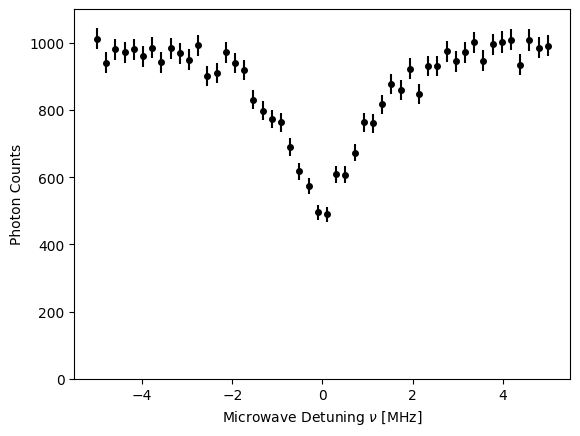

In [ ]:
nu_sweep = np.linspace(-5, 5, 50)
B_true, nu0_true, gamma_true = 1000.0, 0.0, 1.0

N_strong = generate_toy(nu_sweep, B_true, A=500, nu0=nu0_true, gamma=gamma_true)
plt.errorbar(nu_sweep, N_strong, yerr=np.sqrt(N_strong), fmt='ko', markersize=4, label='Toy Data')
plt.ylim(0, 1100)
plt.xlabel("Microwave Detuning $\\nu$ [MHz]")
plt.ylabel("Photon Counts")